# Machine Learning para identificación y predicción del ciclo operativo de una empresa industrial

**Machine Learning aplicado a Finanzas**  
**Alumno:** Alejandro Alvear  
**Unidad de observación:** Empresa–Trimestre  
**Horizonte predictivo:** un trimestre hacia adelante ($t+1$)

## 1. Resumen ejecutivo

- Se utilizaron 48 trimestres de información financiera histórica real y pública,
  sin alterar los valores del caso de estudio.
- El PCA descriptivo produjo un factor interpretable: PC1 explica 54.6% de la varianza
  y sus cargas son positivas en Revenue YoY, Revenue QoQ y margen neto.
- La validación walk-forward generó 22 predicciones realmente fuera de muestra entre
  2020-Q3 y 2025-Q4. Random Forest registró Accuracy 0.545, Balanced Accuracy 0.538
  y Macro F1 0.542.
- Logistic Regression obtuvo Macro F1 0.539: la diferencia de aproximadamente 0.002
  frente a Random Forest es marginal y no demuestra superioridad estructural.
- Los modelos superaron al baseline de persistencia (Macro F1 0.092), pero Contracción
  sigue siendo la principal debilidad del protagonista: recall 0.25 y F1 0.20.
- Revenue YoY fue la variable más influyente. Esto representa asociación predictiva
  dentro del modelo, no causalidad.
- La señal exploratoria 2026-Q1 asigna 47.2% a Expansión y 38.1% a Contracción. Debe
  interpretarse como alerta temprana incierta, no como pronóstico determinístico.
- Evaluación global: **prueba de concepto compartible con caveats**, no un modelo listo
  para producción.

## 2. Problema y motivación

> ¿Es posible predecir, utilizando exclusivamente información financiera disponible
> hasta el trimestre $t$, en qué fase del ciclo operativo se encontrará una empresa
> industrial en el trimestre $t+1$?

Las cuatro fases son Expansión, Desaceleración, Contracción y Recuperación. El resultado
se interpreta como un **sistema de alerta temprana del ciclo operativo**, no como una
decisión gerencial automática.

La prioridad metodológica es evitar *look-ahead bias*: la validación predictiva usa
ventanas expansivas, preprocesamiento ajustado dentro de cada fold y un PCA recalibrado
únicamente con historia disponible hasta el origen de cada predicción.

### Supuestos clave

- Los estados financieros de $t$ están disponibles antes de predecir $t+1$.
- Los montos son CAD millones, salvo EPS.
- No se imputan variables contables estructuralmente ausentes.
- Con 48 trimestres, los resultados son exploratorios y no evidencia causal.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix,
)
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42
MIN_TRAIN_PAIRS = 20
STATE_ORDER = ["Expansión", "Desaceleración", "Contracción", "Recuperación"]
STATE_COLORS = {
    "Expansión": "#2563EB",
    "Desaceleración": "#D4A017",
    "Contracción": "#D97706",
    "Recuperación": "#6B8E23",
}
BLUE = "#2563EB"
GOLD = "#D4A017"
ORANGE = "#D97706"
OLIVE = "#6B8E23"
DARK = "#273142"
LIGHT = "#E8EDF3"

np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)


def find_project_root():
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        expected = candidate / "data/raw/finning_dataset_trimestral_real_2014_2025.xlsx"
        if expected.exists():
            return candidate
    raise FileNotFoundError("No se encontró el Excel fuente desde la ubicación actual.")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data/raw/finning_dataset_trimestral_real_2014_2025.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "outputs/ml_ciclo_empresa_industrial"
FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:", PROJECT_ROOT)
print("Fuente técnica localizada; nombre original conservado solo para trazabilidad.")

Raíz del proyecto: /Users/alejandroalvear/Proyectos/tarea04
Fuente técnica localizada; nombre original conservado solo para trazabilidad.


## 3. Fuente y calidad de datos

Se utilizan datos financieros históricos reales, provenientes de información financiera
pública, con frecuencia trimestral y cobertura 2014-Q1–2025-Q4. La hoja principal se
analiza a nivel **Empresa–Trimestre**.

El nombre original del archivo, el nombre técnico de la hoja y las URLs se conservan
únicamente dentro del código y del libro fuente para trazabilidad académica y
reproducibilidad. No se muestran repetidamente en títulos, gráficos ni narrativa.

In [2]:
workbook = pd.ExcelFile(DATA_PATH)
SOURCE_SHEET = "Finning_Quarterly"  # nombre técnico original; se conserva por trazabilidad
required_sheets = {SOURCE_SHEET, "README", "Sources"}
assert required_sheets.issubset(workbook.sheet_names), "Faltan hojas requeridas"

raw = pd.read_excel(DATA_PATH, sheet_name=SOURCE_SHEET)
readme = pd.read_excel(DATA_PATH, sheet_name="README", header=None, names=["Campo", "Detalle"])
sources = pd.read_excel(DATA_PATH, sheet_name="Sources")

raw["Quarter_End"] = pd.to_datetime(raw["Quarter_End"])
raw = raw.sort_values("Quarter_End").reset_index(drop=True)

required_columns = {
    "Quarter_End", "Year", "Quarter", "Revenue_CAD_m", "Net_Income_CAD_m",
    "EPS_CAD", "Total_Assets_CAD_m", "Long_Term_Debt_CAD_m", "Units", "Source_URL",
}
missing_required = required_columns.difference(raw.columns)
assert not missing_required, f"Faltan columnas: {sorted(missing_required)}"

preview_columns = [
    "Quarter_End", "Year", "Quarter", "Revenue_CAD_m",
    "Net_Income_CAD_m", "EPS_CAD", "Total_Assets_CAD_m", "Long_Term_Debt_CAD_m",
]
visible_readme_fields = [
    "Cobertura", "Frecuencia", "Moneda", "Nota 2018", "Nota 2019", "Nota 2025",
    "Advertencia ML", "Variables derivadas",
]

display(raw[preview_columns].head())
print(f"Dimensión: {raw.shape[0]} trimestres × {raw.shape[1]} columnas")
print(f"Cobertura: {raw.Quarter_End.min():%Y-%m-%d} a {raw.Quarter_End.max():%Y-%m-%d}")
display(readme[readme["Campo"].isin(visible_readme_fields)])

,Quarter_End,Year,Quarter,Revenue_CAD_m,Net_Income_CAD_m,EPS_CAD,Total_Assets_CAD_m,Long_Term_Debt_CAD_m
0,2014-03-31,2014,Q1,1676,68,0.3900,5353.0000,1394.0000
1,2014-06-30,2014,Q2,1768,86,0.5000,5196.0000,1374.0000
2,2014-09-30,2014,Q3,1670,57,0.3300,5237.0000,1409.0000
3,2014-12-31,2014,Q4,1803,107,0.6200,5273.0000,1418.0000
4,2015-03-31,2015,Q1,1519,53,0.3100,5354.0000,1477.0000


Dimensión: 48 trimestres × 14 columnas
Cobertura: 2014-03-31 a 2025-12-31


,Campo,Detalle
1,Cobertura,2014 Q1 a 2025 Q4 (48 trimestres)
2,Frecuencia,Trimestral
3,Moneda,CAD; montos financieros en millones salvo EPS
6,Nota 2018,Los comparativos 2017 fueron restatados por IF...
7,Nota 2019,Revenue/Net income/EPS se recopilaron desde lo...
8,Nota 2025,"Revenue, net income y EPS corresponden a conti..."
9,Advertencia ML,"No usar splits aleatorios. Features, scaler, i..."
10,Variables derivadas,"Revenue_QoQ, Revenue_YoY, NetIncome_YoY y Reve..."


In [3]:
expected_quarters = pd.date_range(
    raw["Quarter_End"].min(), raw["Quarter_End"].max(), freq="QE-DEC"
)
missing_quarters = expected_quarters.difference(raw["Quarter_End"])

availability_rows = []
for column in raw.columns:
    populated = raw[column].notna()
    availability_rows.append({
        "Variable": column,
        "Tipo": str(raw[column].dtype),
        "Disponibles": int(populated.sum()),
        "Faltantes": int((~populated).sum()),
        "% faltante": float((~populated).mean()),
        "Primer dato": raw.loc[populated, "Quarter_End"].min() if populated.any() else pd.NaT,
        "Último dato": raw.loc[populated, "Quarter_End"].max() if populated.any() else pd.NaT,
    })
availability = pd.DataFrame(availability_rows)

numeric_columns = raw.select_dtypes(include=np.number).columns
outlier_rows = []
for column in numeric_columns:
    values = raw[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = raw[column].lt(lower) | raw[column].gt(upper)
    for _, row in raw.loc[mask, ["Quarter_End", column]].iterrows():
        outlier_rows.append({
            "Variable": column, "Trimestre": row["Quarter_End"],
            "Valor": row[column], "Límite inferior": lower, "Límite superior": upper,
        })
outliers = pd.DataFrame(outlier_rows)

quality_table = pd.DataFrame([
    {"Control": "Grano", "Resultado": "Empresa–Trimestre", "Estado": "OK"},
    {"Control": "Continuidad trimestral", "Resultado": f"{len(missing_quarters)} trimestres faltantes", "Estado": "OK" if len(missing_quarters) == 0 else "Revisar"},
    {"Control": "Duplicados exactos", "Resultado": int(raw.duplicated().sum()), "Estado": "OK" if raw.duplicated().sum() == 0 else "Revisar"},
    {"Control": "Fechas duplicadas", "Resultado": int(raw.duplicated("Quarter_End").sum()), "Estado": "OK" if raw.duplicated("Quarter_End").sum() == 0 else "Revisar"},
    {"Control": "URLs de fuente válidas", "Resultado": int(raw["Source_URL"].astype(str).str.startswith("https://").sum()), "Estado": "OK"},
    {"Control": "Outliers IQR (no eliminados)", "Resultado": len(outliers), "Estado": "Documentar"},
])

display(quality_table)
display(availability)
display(outliers)

availability.to_csv(OUTPUT_DIR / "tabla_calidad_disponibilidad.csv", index=False)
outliers.to_csv(OUTPUT_DIR / "tabla_outliers_iqr.csv", index=False)

assert raw.duplicated("Quarter_End").sum() == 0
assert len(missing_quarters) == 0
assert raw["Units"].eq("CAD millions").all()

,Control,Resultado,Estado
0,Grano,Empresa–Trimestre,OK
1,Continuidad trimestral,0 trimestres faltantes,OK
2,Duplicados exactos,0,OK
3,Fechas duplicadas,0,OK
4,URLs de fuente válidas,48,OK
5,Outliers IQR (no eliminados),10,Documentar


,Variable,Tipo,Disponibles,Faltantes,% faltante,Primer dato,Último dato
0,Quarter_End,datetime64[us],48,0,0.0000,2014-03-31,2025-12-31
1,Year,int64,48,0,0.0000,2014-03-31,2025-12-31
2,Quarter,str,48,0,0.0000,2014-03-31,2025-12-31
3,Revenue_CAD_m,int64,48,0,0.0000,2014-03-31,2025-12-31
4,Net_Income_CAD_m,int64,48,0,0.0000,2014-03-31,2025-12-31
5,EPS_CAD,float64,48,0,0.0000,2014-03-31,2025-12-31
6,Total_Assets_CAD_m,float64,40,8,0.1667,2014-03-31,2024-12-31
7,Long_Term_Debt_CAD_m,float64,40,8,0.1667,2014-03-31,2024-12-31
8,Units,str,48,0,0.0000,2014-03-31,2025-12-31
9,Source_URL,str,48,0,0.0000,2014-03-31,2025-12-31


,Variable,Trimestre,Valor,Límite inferior,Límite superior
0,Net_Income_CAD_m,2015-12-31,-309.0000,-42.8750,212.1250
1,EPS_CAD,2015-12-31,-1.8200,-0.4400,1.5600
2,Long_Term_Debt_CAD_m,2022-06-30,917.0000,928.5000,1802.5000
3,Long_Term_Debt_CAD_m,2023-03-31,928.0000,928.5000,1802.5000
4,NetIncome_YoY,2015-12-31,-3.8879,-1.2687,1.4796
5,NetIncome_YoY,2017-03-31,2.1333,-1.2687,1.4796
6,NetIncome_YoY,2017-06-30,10.2000,-1.2687,1.4796
7,NetIncome_YoY,2017-12-31,6.3333,-1.2687,1.4796
8,NetIncome_YoY,2019-09-30,2.0400,-1.2687,1.4796
9,NetIncome_YoY,2021-06-30,4.0556,-1.2687,1.4796


### Diagnóstico de calidad

- Revenue, utilidad neta y EPS están completos durante 2014-Q1–2025-Q4.
- Activos y deuda faltan en los cuatro trimestres de 2025 (ocho celdas en total). El
  README explica que se omitieron para evitar mezclar bases no comparables; no se imputan.
- El outlier 2015-Q4 en utilidad neta y EPS se conserva porque representa un hecho
  financiero observado, no un error demostrado.
- Los comparativos 2017 fueron restatados bajo IFRS 15/IFRS 9; 2025 usa continuing
  operations/restated basis. Estos cambios limitan la comparabilidad perfecta.
- New Equipment, Product Support, EBIT, EBITDA, FCF, Working Capital y Backlog no están
  disponibles. Se omiten en lugar de inventarlos.

## 4. Análisis exploratorio

Los gráficos usan líneas para series temporales, barras para cargas y distribución, y
una paleta explícita. No se utilizan ejes duales ni escalas truncadas engañosas.

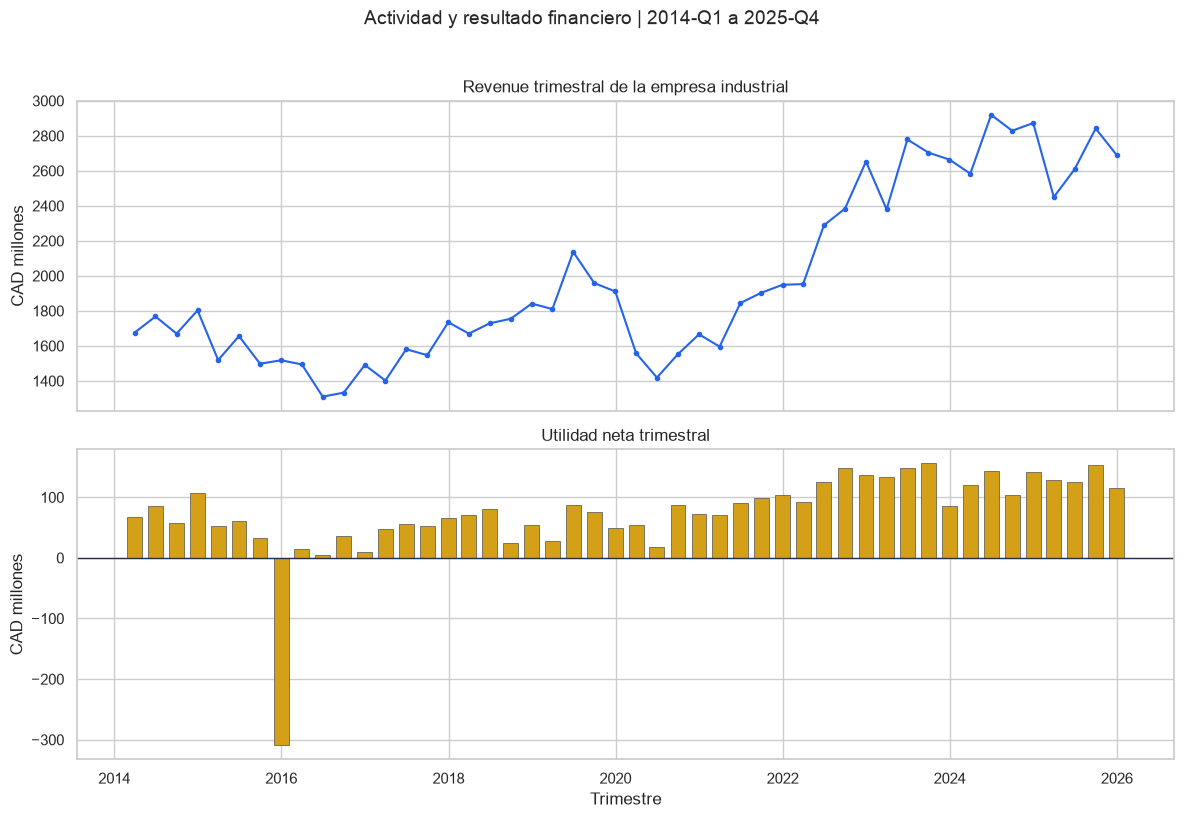

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(raw["Quarter_End"], raw["Revenue_CAD_m"], color=BLUE, marker="o", ms=3)
axes[0].set(title="Revenue trimestral de la empresa industrial", ylabel="CAD millones")
axes[1].bar(raw["Quarter_End"], raw["Net_Income_CAD_m"], width=65, color=GOLD, edgecolor=DARK, linewidth=0.4)
axes[1].axhline(0, color=DARK, linewidth=1)
axes[1].set(title="Utilidad neta trimestral", xlabel="Trimestre", ylabel="CAD millones")
fig.suptitle("Actividad y resultado financiero | 2014-Q1 a 2025-Q4", y=1.02, fontsize=14)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_revenue_net_income.png", dpi=150, bbox_inches="tight")
plt.show()

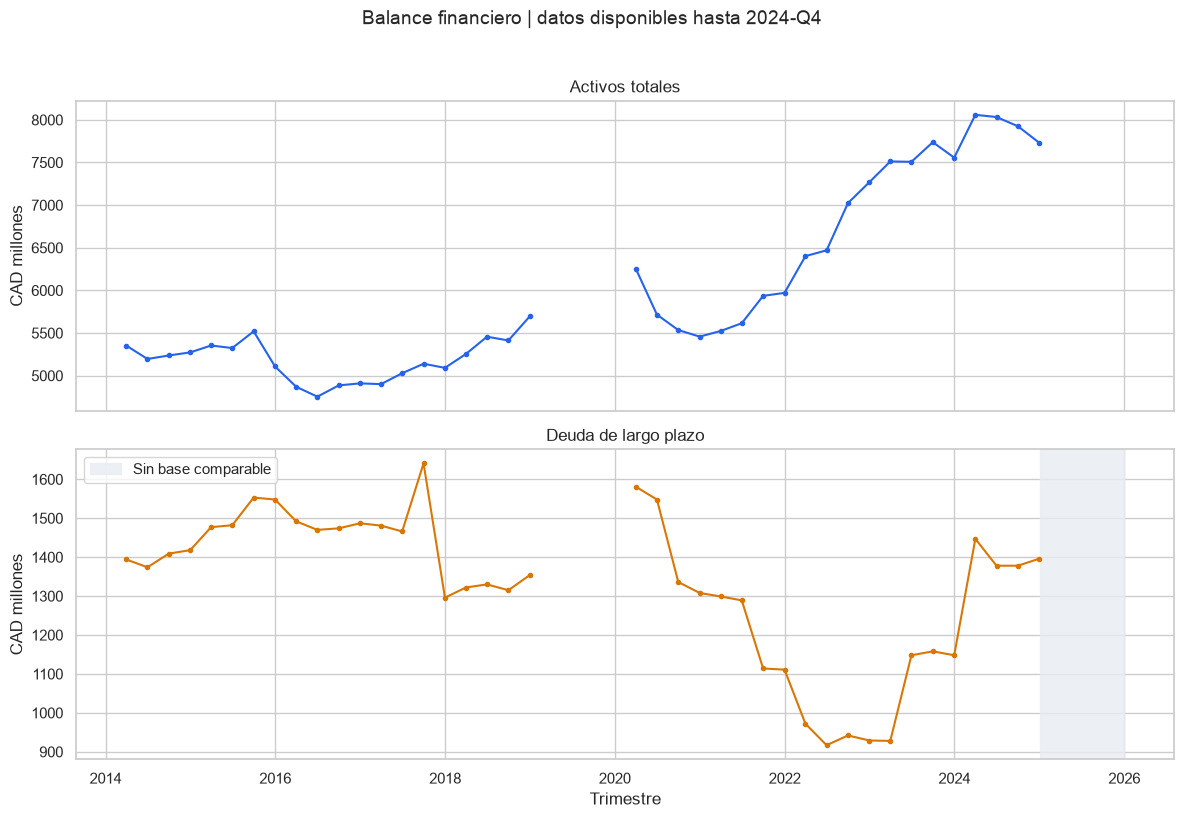

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(raw["Quarter_End"], raw["Total_Assets_CAD_m"], color=BLUE, marker="o", ms=3)
axes[0].set(title="Activos totales", ylabel="CAD millones")
axes[1].plot(raw["Quarter_End"], raw["Long_Term_Debt_CAD_m"], color=ORANGE, marker="o", ms=3)
axes[1].set(title="Deuda de largo plazo", xlabel="Trimestre", ylabel="CAD millones")
axes[1].axvspan(pd.Timestamp("2025-01-01"), raw["Quarter_End"].max(), color=LIGHT, alpha=0.8, label="Sin base comparable")
axes[1].legend(loc="upper left")
fig.suptitle("Balance financiero | datos disponibles hasta 2024-Q4", y=1.02, fontsize=14)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "02_assets_debt.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Feature engineering

Las variables se recalculan desde las columnas financieras base para no depender de
fórmulas almacenadas en Excel. Todas usan información de $t$ o anterior.

La selección final es deliberadamente pequeña: crecimiento de revenue, momentum,
margen neto y desviación respecto de la media móvil. Activos y deuda se excluyen del
modelo final por su ausencia estructural en 2025.

In [6]:
financials = raw.set_index("Quarter_End").copy()
financials["Revenue_YoY"] = financials["Revenue_CAD_m"].pct_change(4)
financials["Revenue_QoQ"] = financials["Revenue_CAD_m"].pct_change(1)
financials["Revenue_Momentum"] = financials["Revenue_YoY"].diff(1)
financials["Revenue_MA4_calc"] = financials["Revenue_CAD_m"].rolling(4).mean()
financials["Revenue_vs_MA4"] = financials["Revenue_CAD_m"] / financials["Revenue_MA4_calc"] - 1
financials["Net_Margin"] = financials["Net_Income_CAD_m"] / financials["Revenue_CAD_m"]
financials["Net_Margin_YoY_Change"] = financials["Net_Margin"] - financials["Net_Margin"].shift(4)
financials["Debt_to_Assets"] = financials["Long_Term_Debt_CAD_m"] / financials["Total_Assets_CAD_m"]

MODEL_FEATURES = [
    "Revenue_YoY", "Revenue_QoQ", "Revenue_Momentum",
    "Net_Margin", "Net_Margin_YoY_Change", "Revenue_vs_MA4",
]
PCA_FEATURES = ["Revenue_YoY", "Revenue_QoQ", "Net_Margin"]

feature_lineage = pd.DataFrame([
    ["Revenue_YoY", "Revenue(t) / Revenue(t-4) - 1", "t, t-4", 0],
    ["Revenue_QoQ", "Revenue(t) / Revenue(t-1) - 1", "t, t-1", 0],
    ["Revenue_Momentum", "Revenue_YoY(t) - Revenue_YoY(t-1)", "t a t-5", 0],
    ["Net_Margin", "Net Income(t) / Revenue(t)", "t", 0],
    ["Net_Margin_YoY_Change", "Net_Margin(t) - Net_Margin(t-4)", "t, t-4", 0],
    ["Revenue_vs_MA4", "Revenue(t) / MA4(t) - 1", "t a t-3", 0],
], columns=["Feature", "Definición", "Información utilizada", "Máximo adelanto"])

assert feature_lineage["Máximo adelanto"].le(0).all(), "Se detectó una feature futura"
direct_yoy = financials["Revenue_CAD_m"] / financials["Revenue_CAD_m"].shift(4) - 1
assert np.allclose(financials["Revenue_YoY"].dropna(), direct_yoy.dropna())
display(feature_lineage)
display(financials[MODEL_FEATURES].describe().T)

,Feature,Definición,Información utilizada,Máximo adelanto
0,Revenue_YoY,Revenue(t) / Revenue(t-4) - 1,"t, t-4",0
1,Revenue_QoQ,Revenue(t) / Revenue(t-1) - 1,"t, t-1",0
2,Revenue_Momentum,Revenue_YoY(t) - Revenue_YoY(t-1),t a t-5,0
3,Net_Margin,Net Income(t) / Revenue(t),t,0
4,Net_Margin_YoY_Change,Net_Margin(t) - Net_Margin(t-4),"t, t-4",0
5,Revenue_vs_MA4,Revenue(t) / MA4(t) - 1,t a t-3,0


,count,mean,std,min,25%,50%,75%,max
Revenue_YoY,44.0000,0.0512,0.1559,-0.3360,-0.0634,0.0562,0.1752,0.3612
Revenue_QoQ,47.0000,0.0141,0.0908,-0.1847,-0.0397,0.0150,0.0845,0.1807
Revenue_Momentum,43.0000,0.0007,0.1117,-0.1968,-0.0735,-0.0045,0.0803,0.2758
Net_Margin,48.0000,0.0345,0.0380,-0.2036,0.0331,0.0418,0.0498,0.0625
Net_Margin_YoY_Change,44.0000,0.0003,0.0539,-0.2629,-0.0085,0.0011,0.0128,0.2096
Revenue_vs_MA4,45.0000,0.0164,0.0747,-0.1762,-0.0221,0.0225,0.0688,0.1437


## 6. Construcción del Índice de Ciclo Operativo mediante PCA

### PCA descriptivo

El PCA descriptivo se ajusta sobre la historia disponible y se utiliza para análisis
retrospectivo, interpretación y visualización del ciclo. **No participa directamente
en las métricas out-of-time.**

Utiliza Revenue YoY, Revenue QoQ y margen neto: actividad interanual, cambio trimestral
y rentabilidad. No incluye caja ni apalancamiento porque esas variables no existen de
manera comparable en toda la muestra.

Se estandariza antes del PCA. PC1 solo se denomina ICO si explica al menos 40% de la
varianza y sus cargas muestran una dirección económica común. El signo se orienta para
que una carga positiva de Revenue YoY represente mejores condiciones operativas.

> **PCA descriptivo ≠ PCA walk-forward.** El primero resume retrospectivamente la
> historia completa; el segundo se recalcula dentro de cada ventana temporal.

In [7]:
cycle_input = financials.dropna(subset=PCA_FEATURES).copy()
cycle_scaler = StandardScaler()
cycle_z = cycle_scaler.fit_transform(cycle_input[PCA_FEATURES])
cycle_pca = PCA(random_state=RANDOM_STATE).fit(cycle_z)

orientation = 1 if cycle_pca.components_[0][PCA_FEATURES.index("Revenue_YoY")] >= 0 else -1
pc1_loadings = pd.Series(
    cycle_pca.components_[0] * orientation,
    index=PCA_FEATURES,
    name="Carga_PC1",
)
pc_scores = cycle_pca.transform(cycle_z)[:, 0] * orientation

pc1_reasonable = (
    cycle_pca.explained_variance_ratio_[0] >= 0.40
    and (pc1_loadings > 0).sum() >= 2
)
if not pc1_reasonable:
    raise ValueError("PC1 no cumple el criterio mínimo para denominarse ICO")

historical_cycle = pd.DataFrame(index=cycle_input.index)
historical_cycle["ICO"] = pc_scores
historical_cycle["Delta_ICO"] = historical_cycle["ICO"].diff()

print(f"Varianza explicada por PC1: {cycle_pca.explained_variance_ratio_[0]:.2%}")
print(f"Varianza acumulada PC1+PC2: {cycle_pca.explained_variance_ratio_[:2].sum():.2%}")
display(pc1_loadings.to_frame())

pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(PCA_FEATURES))],
    "Varianza explicada": cycle_pca.explained_variance_ratio_,
    "Varianza acumulada": np.cumsum(cycle_pca.explained_variance_ratio_),
}).to_csv(OUTPUT_DIR / "pca_varianza_explicada.csv", index=False)
pc1_loadings.to_csv(OUTPUT_DIR / "pca_loadings_pc1.csv")

Varianza explicada por PC1: 54.56%
Varianza acumulada PC1+PC2: 84.41%


,Carga_PC1
Revenue_YoY,0.6743
Revenue_QoQ,0.5617
Net_Margin,0.4794


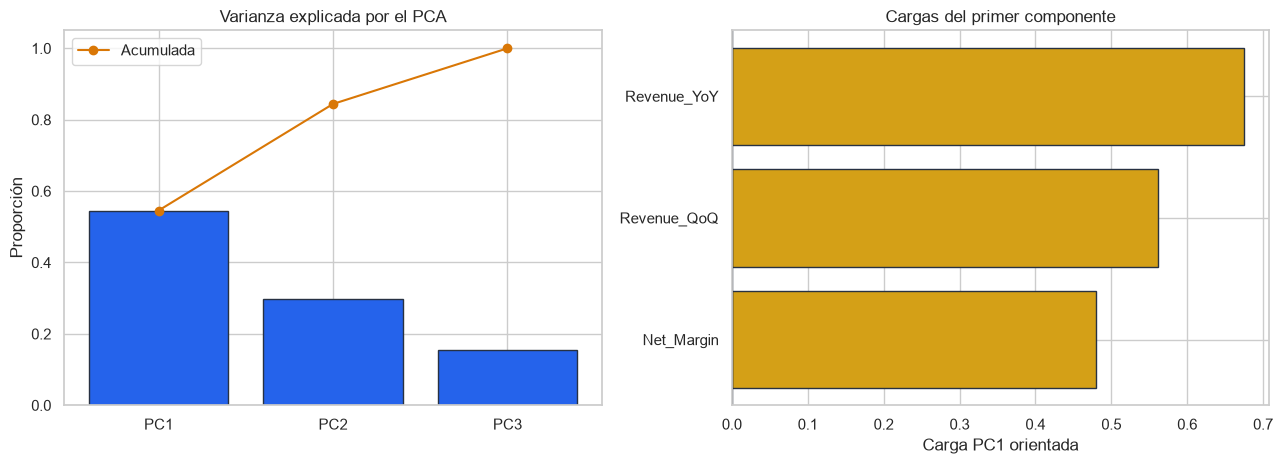

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
explained = cycle_pca.explained_variance_ratio_
axes[0].bar([f"PC{i+1}" for i in range(len(explained))], explained, color=BLUE, edgecolor=DARK)
axes[0].plot([f"PC{i+1}" for i in range(len(explained))], np.cumsum(explained), color=ORANGE, marker="o", label="Acumulada")
axes[0].set(title="Varianza explicada por el PCA", ylabel="Proporción")
axes[0].set_ylim(0, 1.05)
axes[0].legend()

ordered_loadings = pc1_loadings.sort_values()
axes[1].barh(ordered_loadings.index, ordered_loadings.values, color=GOLD, edgecolor=DARK)
axes[1].axvline(0, color=DARK, linewidth=1)
axes[1].set(title="Cargas del primer componente", xlabel="Carga PC1 orientada")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "03_pca_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Identificación de las cuatro fases

Se aplica la regla operacional sobre el nivel y el cambio del ICO. Las etiquetas son
resultado del método; no se corrigen manualmente para que coincidan con una narrativa.

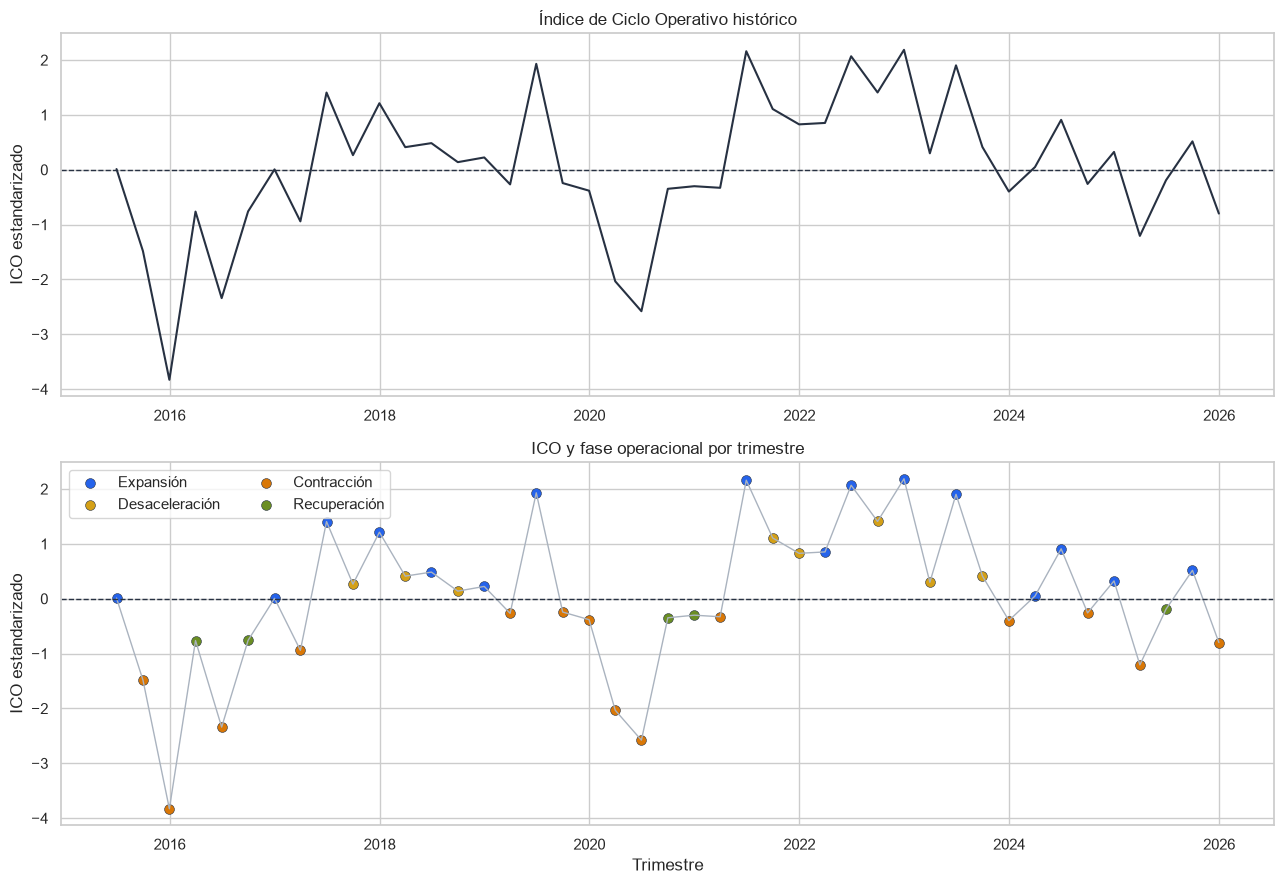

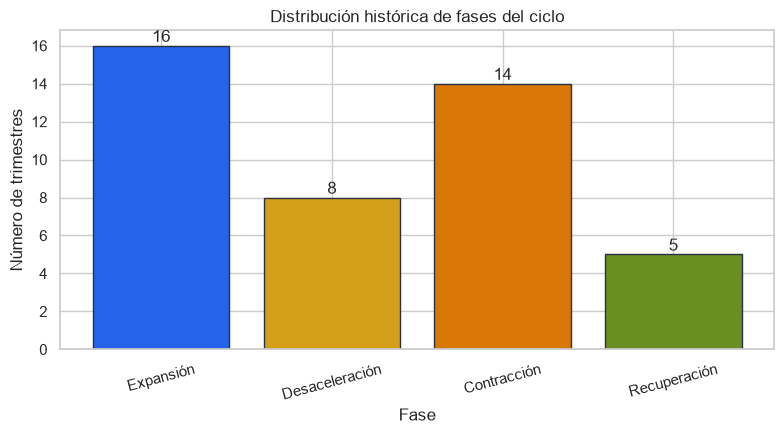

,Trimestres
Estado_Ciclo,
Expansión,16
Desaceleración,8
Contracción,14
Recuperación,5


In [9]:
def classify_cycle(ico, delta):
    conditions = [
        (ico > 0) & (delta > 0),
        (ico > 0) & (delta <= 0),
        (ico <= 0) & (delta < 0),
        (ico <= 0) & (delta >= 0),
    ]
    return pd.Series(
        np.select(conditions, STATE_ORDER, default=None),
        index=ico.index,
        dtype="object",
    )


historical_cycle["Estado_Ciclo"] = classify_cycle(
    historical_cycle["ICO"], historical_cycle["Delta_ICO"]
)
historical_cycle = historical_cycle.dropna(subset=["Estado_Ciclo"])

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
axes[0].plot(historical_cycle.index, historical_cycle["ICO"], color=DARK, linewidth=1.5)
axes[0].axhline(0, color=DARK, linestyle="--", linewidth=1)
axes[0].set(title="Índice de Ciclo Operativo histórico", ylabel="ICO estandarizado")

axes[1].plot(historical_cycle.index, historical_cycle["ICO"], color="#AAB3BF", linewidth=1)
for state in STATE_ORDER:
    subset = historical_cycle[historical_cycle["Estado_Ciclo"] == state]
    axes[1].scatter(subset.index, subset["ICO"], color=STATE_COLORS[state], s=50, label=state, edgecolor=DARK, linewidth=0.4)
axes[1].axhline(0, color=DARK, linestyle="--", linewidth=1)
axes[1].set(title="ICO y fase operacional por trimestre", xlabel="Trimestre", ylabel="ICO estandarizado")
axes[1].legend(ncol=2)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "04_ico_states.png", dpi=150, bbox_inches="tight")
plt.show()

class_counts = historical_cycle["Estado_Ciclo"].value_counts().reindex(STATE_ORDER, fill_value=0)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(class_counts.index, class_counts.values, color=[STATE_COLORS[s] for s in class_counts.index], edgecolor=DARK)
ax.set(title="Distribución histórica de fases del ciclo", xlabel="Fase", ylabel="Número de trimestres")
ax.tick_params(axis="x", rotation=15)
for i, value in enumerate(class_counts.values):
    ax.text(i, value + 0.2, str(value), ha="center")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "05_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

display(class_counts.rename("Trimestres").to_frame())

## 8. Validación económica del ciclo

Se inspeccionan 2019-Q4–2021-Q4 para evaluar deterioro de 2020 y recuperación posterior.
La revisión es diagnóstica: no modifica etiquetas.

El benchmark solicitado basado en New Equipment Revenue no puede construirse porque esa
serie no existe en el Excel. La omisión se documenta para evitar usar datos simulados o
aproximaciones no trazables.

,Revenue_CAD_m,Revenue_YoY,Net_Income_CAD_m,Net_Margin,ICO,Delta_ICO,Estado_Ciclo
Quarter_End,,,,,,,
2019-12-31,1911,0.0375,50,0.0262,-0.3822,-0.1390,Contracción
2020-03-31,1558,-0.1392,54,0.0347,-2.0340,-1.6518,Contracción
2020-06-30,1419,-0.3360,18,0.0127,-2.5786,-0.5446,Contracción
2020-09-30,1553,-0.2072,88,0.0567,-0.3477,2.2309,Recuperación
2020-12-31,1666,-0.1282,72,0.0432,-0.3003,0.0475,Recuperación
2021-03-31,1596,0.0244,70,0.0439,-0.3294,-0.0291,Contracción
2021-06-30,1845,0.3002,91,0.0493,2.1598,2.4891,Expansión
2021-09-30,1904,0.2260,99,0.0520,1.1068,-1.0530,Desaceleración
2021-12-31,1949,0.1699,104,0.0534,0.8267,-0.2800,Desaceleración


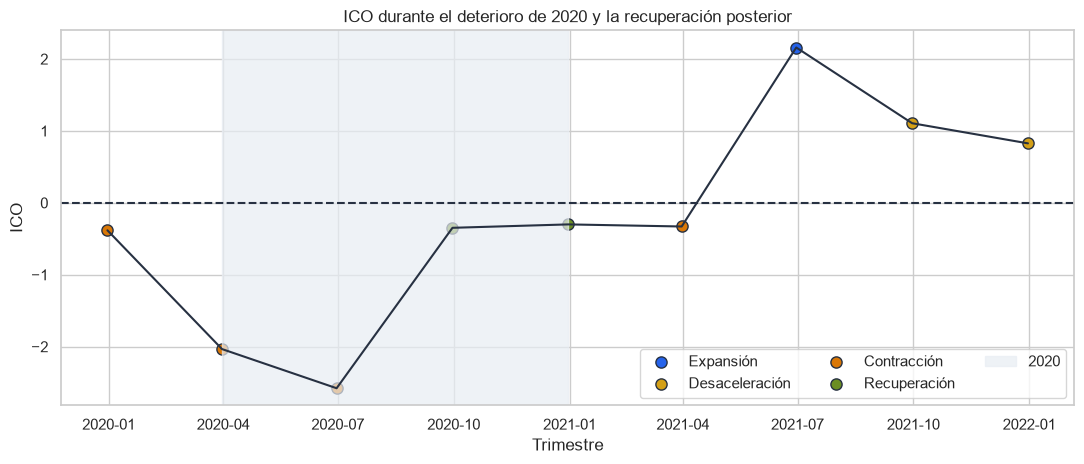

In [10]:
economic_check = (
    financials[["Revenue_CAD_m", "Revenue_YoY", "Net_Income_CAD_m", "Net_Margin"]]
    .join(historical_cycle[["ICO", "Delta_ICO", "Estado_Ciclo"]], how="left")
    .loc["2019-12-31":"2021-12-31"]
)
display(economic_check)

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(economic_check.index, economic_check["ICO"], color=DARK, linewidth=1.5)
for state in STATE_ORDER:
    subset = economic_check[economic_check["Estado_Ciclo"] == state]
    ax.scatter(subset.index, subset["ICO"], color=STATE_COLORS[state], s=65, label=state, edgecolor=DARK)
ax.axhline(0, color=DARK, linestyle="--")
ax.axvspan(pd.Timestamp("2020-03-31"), pd.Timestamp("2020-12-31"), color=LIGHT, alpha=0.7, label="2020")
ax.set(title="ICO durante el deterioro de 2020 y la recuperación posterior", xlabel="Trimestre", ylabel="ICO")
ax.legend(ncol=3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "06_economic_validation_2020.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Construcción del target $t+1$ y control de leakage

El experimento usa $X(t) \rightarrow Estado\_Ciclo(t+1)$.

### PCA dentro del walk-forward

Para cada origen temporal:

1. scaler y PCA se ajustan solo con indicadores de ciclo disponibles hasta $t$;
2. las etiquetas históricas de entrenamiento se recalculan bajo esa base;
3. los modelos se ajustan con pares cuyo target ya era observable en $t$;
4. se transforma $t+1$ con el PCA del fold únicamente para construir la etiqueta real;
5. ninguna feature contiene datos posteriores a $t$.

Solo este PCA fold-local participa en las métricas out-of-time. Esta separación evita
que información futura determine el escalamiento, las cargas o las etiquetas usadas
para evaluar cada predicción.

> **PCA descriptivo ≠ PCA walk-forward.** Las etiquetas pueden revisarse cuando crece
> la ventana porque la base PCA cambia ligeramente. Es una limitación inherente a un
> target latente y se reporta como riesgo de modelo.

In [11]:
def fit_fold_cycle(financial_frame, origin_position):
    """Ajusta el PCA con historia <= t y etiqueta hasta t+1 con esa misma base."""
    fit_slice = financial_frame.iloc[: origin_position + 1].dropna(subset=PCA_FEATURES)
    score_slice = financial_frame.iloc[: origin_position + 2].dropna(subset=PCA_FEATURES)

    scaler = StandardScaler().fit(fit_slice[PCA_FEATURES])
    pca = PCA(random_state=RANDOM_STATE).fit(scaler.transform(fit_slice[PCA_FEATURES]))
    sign = 1 if pca.components_[0][PCA_FEATURES.index("Revenue_YoY")] >= 0 else -1

    scores = pd.Series(
        pca.transform(scaler.transform(score_slice[PCA_FEATURES]))[:, 0] * sign,
        index=score_slice.index,
        name="ICO_fold",
    )
    labels = classify_cycle(scores, scores.diff()).dropna()
    return scores, labels, float(pca.explained_variance_ratio_[0])


MODEL_TEMPLATES = {
    "Logistic Regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(
            C=0.5, max_iter=3000, class_weight="balanced",
            solver="lbfgs", random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=300, max_depth=3, min_samples_leaf=3,
            max_features="sqrt", class_weight="balanced_subsample",
            random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingClassifier(
            n_estimators=80, learning_rate=0.03, max_depth=2,
            min_samples_leaf=3, subsample=0.8, random_state=RANDOM_STATE,
        )),
    ]),
}


def fit_model(model_name, model, X_train, y_train):
    fitted = clone(model)
    if model_name == "Gradient Boosting":
        weights = compute_sample_weight(class_weight="balanced", y=y_train)
        fitted.fit(X_train, y_train, model__sample_weight=weights)
    else:
        fitted.fit(X_train, y_train)
    return fitted


def run_expanding_walk_forward(financial_frame):
    rows = []
    dates = financial_frame.index

    for origin_position in range(len(financial_frame) - 1):
        origin_date = dates[origin_position]
        next_date = dates[origin_position + 1]
        if financial_frame.loc[origin_date, MODEL_FEATURES].isna().any():
            continue

        scores, labels, fold_pc1_variance = fit_fold_cycle(financial_frame, origin_position)
        if next_date not in labels.index or origin_date not in labels.index:
            continue

        training_feature_dates = []
        training_labels = []
        for target_date in labels.index[labels.index <= origin_date]:
            target_position = dates.get_loc(target_date)
            if target_position == 0:
                continue
            feature_date = dates[target_position - 1]
            if financial_frame.loc[feature_date, MODEL_FEATURES].isna().any():
                continue
            training_feature_dates.append(feature_date)
            training_labels.append(labels.loc[target_date])

        y_train = pd.Series(training_labels, index=training_feature_dates, name="Target_t_plus_1")
        if len(y_train) < MIN_TRAIN_PAIRS or set(y_train.unique()) != set(STATE_ORDER):
            continue

        X_train = financial_frame.loc[training_feature_dates, MODEL_FEATURES]
        X_test = financial_frame.loc[[origin_date], MODEL_FEATURES]

        result = {
            "Origin_t": origin_date,
            "Target_t_plus_1": next_date,
            "Actual": labels.loc[next_date],
            "Baseline Persistencia": labels.loc[origin_date],
            "Baseline Mayoritaria": y_train.value_counts().idxmax(),
            "N_train": len(y_train),
            "PC1_variance_fold": fold_pc1_variance,
        }
        for model_name, template in MODEL_TEMPLATES.items():
            fitted = fit_model(model_name, template, X_train, y_train)
            result[model_name] = fitted.predict(X_test)[0]
        rows.append(result)

    return pd.DataFrame(rows)


walk_predictions = run_expanding_walk_forward(financials)
assert not walk_predictions.empty, "No fue posible formar folds walk-forward"
assert walk_predictions["Target_t_plus_1"].is_monotonic_increasing
assert walk_predictions["Origin_t"].lt(walk_predictions["Target_t_plus_1"]).all()

display(walk_predictions.head())
print(f"Predicciones out-of-time: {len(walk_predictions)}")
print(f"Ventana evaluada: {walk_predictions.Target_t_plus_1.min():%Y-%m-%d} a {walk_predictions.Target_t_plus_1.max():%Y-%m-%d}")
walk_predictions.to_csv(OUTPUT_DIR / "predicciones_walk_forward.csv", index=False)

,Origin_t,Target_t_plus_1,Actual,Baseline Persistencia,Baseline Mayoritaria,N_train,PC1_variance_fold,Logistic Regression,Random Forest,Gradient Boosting
0,2020-06-30,2020-09-30,Recuperación,Contracción,Desaceleración,20,0.5575,Recuperación,Recuperación,Recuperación
1,2020-09-30,2020-12-31,Expansión,Recuperación,Contracción,21,0.5224,Contracción,Contracción,Contracción
2,2020-12-31,2021-03-31,Desaceleración,Expansión,Expansión,22,0.5097,Expansión,Desaceleración,Desaceleración
3,2021-03-31,2021-06-30,Expansión,Desaceleración,Expansión,23,0.5070,Expansión,Expansión,Expansión
4,2021-06-30,2021-09-30,Desaceleración,Expansión,Contracción,24,0.5355,Desaceleración,Desaceleración,Desaceleración


Predicciones out-of-time: 22
Ventana evaluada: 2020-09-30 a 2025-12-31


### Estabilidad temporal del PCA walk-forward

Se examina `PC1_variance_fold` en las 22 ventanas evaluadas. Esta revisión no altera
el PCA: solo mide si la capacidad explicativa de PC1 permanece razonablemente estable.

,PC1 variance fold
Media,0.5503
Mediana,0.5575
Mínimo,0.5070
Máximo,0.5749
Desviación estándar,0.0185


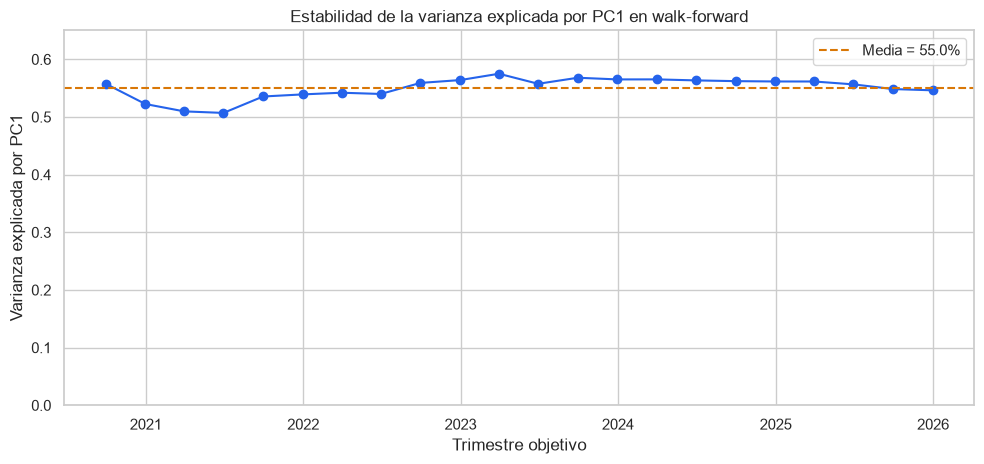

PC1 explica en promedio 55.0%; el rango entre mínimo y máximo es 6.8%. La dispersión es acotada y no muestra pérdida sostenida de capacidad explicativa.


In [12]:
pc1_stability = walk_predictions["PC1_variance_fold"].agg(
    ["mean", "median", "min", "max", "std"]
).rename({
    "mean": "Media", "median": "Mediana", "min": "Mínimo",
    "max": "Máximo", "std": "Desviación estándar",
})
display(pc1_stability.rename("PC1 variance fold").to_frame())

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(
    walk_predictions["Target_t_plus_1"],
    walk_predictions["PC1_variance_fold"],
    color=BLUE, marker="o", linewidth=1.5,
)
ax.axhline(pc1_stability["Media"], color=ORANGE, linestyle="--",
           label=f"Media = {pc1_stability['Media']:.1%}")
ax.set_ylim(0, 0.65)
ax.set(
    title="Estabilidad de la varianza explicada por PC1 en walk-forward",
    xlabel="Trimestre objetivo", ylabel="Varianza explicada por PC1",
)
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "09_pc1_stability.png", dpi=150, bbox_inches="tight")
plt.show()

stability_range = pc1_stability["Máximo"] - pc1_stability["Mínimo"]
print(
    f"PC1 explica en promedio {pc1_stability['Media']:.1%}; "
    f"el rango entre mínimo y máximo es {stability_range:.1%}. "
    "La dispersión es acotada y no muestra pérdida sostenida de capacidad explicativa."
)
pc1_stability.rename("value").to_csv(OUTPUT_DIR / "estabilidad_pc1_walk_forward.csv")

## 10–15. Baselines, modelos y comparación

Se mantienen dos reglas simples: persistencia del estado actual y clase mayoritaria
observada exclusivamente en entrenamiento. Los baselines permiten comprobar si el
Machine Learning aporta capacidad predictiva adicional.

Se comparan Logistic Regression regularizada, Random Forest restringido y Gradient
Boosting conservador. No se realiza una nueva optimización ni búsqueda de
hiperparámetros: las configuraciones existentes priorizan regularización, baja
profundidad y estabilidad.

Macro F1 es la métrica principal porque pondera por igual las cuatro fases y evita que
una clase frecuente domine la evaluación.

In [13]:
PREDICTION_COLUMNS = [
    "Baseline Persistencia", "Baseline Mayoritaria",
    "Logistic Regression", "Random Forest", "Gradient Boosting",
]


def score_predictions(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, labels=STATE_ORDER, average="macro", zero_division=0),
    }


comparison_rows = []
for model_name in PREDICTION_COLUMNS:
    comparison_rows.append({"Modelo": model_name, **score_predictions(walk_predictions["Actual"], walk_predictions[model_name])})
model_comparison = pd.DataFrame(comparison_rows).sort_values("Macro F1", ascending=False).reset_index(drop=True)

ml_only = model_comparison[model_comparison["Modelo"].isin(MODEL_TEMPLATES)]
protagonist = ml_only.sort_values(["Macro F1", "Balanced Accuracy", "Accuracy"], ascending=False).iloc[0]["Modelo"]
baseline_f1 = model_comparison.loc[model_comparison["Modelo"] == "Baseline Persistencia", "Macro F1"].iloc[0]
protagonist_f1 = model_comparison.loc[model_comparison["Modelo"] == protagonist, "Macro F1"].iloc[0]
beats_baseline = bool(protagonist_f1 > baseline_f1)

display(model_comparison)
print("Modelo ML protagonista:", protagonist)
print("¿Supera al baseline de persistencia?:", beats_baseline)
rf_macro_f1 = model_comparison.loc[model_comparison["Modelo"] == "Random Forest", "Macro F1"].iloc[0]
log_macro_f1 = model_comparison.loc[model_comparison["Modelo"] == "Logistic Regression", "Macro F1"].iloc[0]
rf_log_gap = rf_macro_f1 - log_macro_f1
print(f"Brecha Macro F1 Random Forest − Logistic Regression: {rf_log_gap:.4f}")
display(Markdown(
    f"Random Forest registra el mayor Macro F1 observado ({rf_macro_f1:.3f}), "
    f"pero la diferencia frente a Logistic Regression ({log_macro_f1:.3f}) es "
    f"solo {rf_log_gap:.3f}. Con 22 predicciones OOT, esto no constituye evidencia "
    "de superioridad estructural."
))
model_comparison.to_csv(OUTPUT_DIR / "comparacion_modelos.csv", index=False)

reports = {}
for model_name in ["Baseline Persistencia", *MODEL_TEMPLATES.keys()]:
    report = classification_report(
        walk_predictions["Actual"], walk_predictions[model_name],
        labels=STATE_ORDER, output_dict=True, zero_division=0,
    )
    reports[model_name] = pd.DataFrame(report).T

display(reports[protagonist].loc[STATE_ORDER, ["precision", "recall", "f1-score", "support"]])
reports[protagonist].to_csv(OUTPUT_DIR / "metricas_por_clase_modelo_protagonista.csv")

,Modelo,Accuracy,Balanced Accuracy,Macro F1
0,Random Forest,0.5455,0.5375,0.5417
1,Logistic Regression,0.5455,0.5208,0.5393
2,Gradient Boosting,0.5455,0.5375,0.5056
3,Baseline Persistencia,0.1364,0.0917,0.0917
4,Baseline Mayoritaria,0.0909,0.0500,0.0556


Modelo ML protagonista: Random Forest
¿Supera al baseline de persistencia?: True
Brecha Macro F1 Random Forest − Logistic Regression: 0.0023


Random Forest registra el mayor Macro F1 observado (0.542), pero la diferencia frente a Logistic Regression (0.539) es solo 0.002. Con 22 predicciones OOT, esto no constituye evidencia de superioridad estructural.

,precision,recall,f1-score,support
Expansión,0.6667,0.4000,0.5000,10.0000
Desaceleración,0.6667,1.0000,0.8000,6.0000
Contracción,0.1667,0.2500,0.2000,4.0000
Recuperación,1.0000,0.5000,0.6667,2.0000


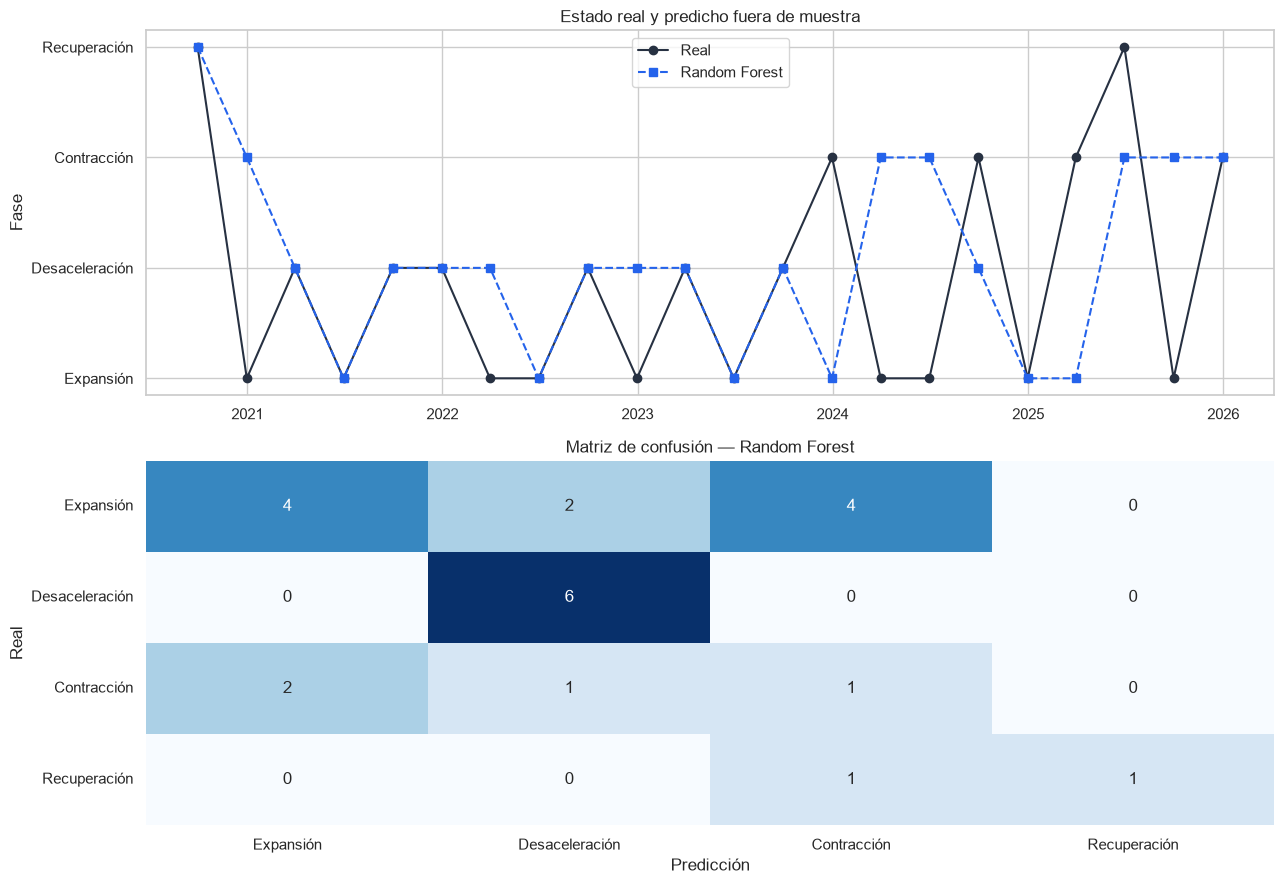

In [14]:
state_to_number = {state: index for index, state in enumerate(STATE_ORDER)}

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
axes[0].plot(
    walk_predictions["Target_t_plus_1"],
    walk_predictions["Actual"].map(state_to_number),
    color=DARK, marker="o", label="Real",
)
axes[0].plot(
    walk_predictions["Target_t_plus_1"],
    walk_predictions[protagonist].map(state_to_number),
    color=BLUE, marker="s", linestyle="--", label=protagonist,
)
axes[0].set_yticks(range(len(STATE_ORDER)), STATE_ORDER)
axes[0].set(title="Estado real y predicho fuera de muestra", ylabel="Fase")
axes[0].legend()

matrix = confusion_matrix(
    walk_predictions["Actual"], walk_predictions[protagonist], labels=STATE_ORDER
)
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1],
            xticklabels=STATE_ORDER, yticklabels=STATE_ORDER)
axes[1].set(title=f"Matriz de confusión — {protagonist}", xlabel="Predicción", ylabel="Real")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "07_out_of_time_and_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Interpretabilidad

Para interpretar, los modelos se reajustan sobre todos los pares históricos disponibles.
Este refit es explicativo y **no sustituye** las métricas walk-forward. Se muestran
coeficientes de Logistic Regression e importancias de los modelos de árboles.

Revenue YoY puede ser relevante porque compara el nivel de actividad con el mismo
trimestre del año anterior, reduciendo parte de la estacionalidad y capturando cambios
persistentes de demanda. Su importancia se interpreta como **asociación predictiva** y
capacidad para la clasificación dentro del modelo, nunca como efecto causal.

,Revenue_YoY,Revenue_QoQ,Revenue_Momentum,Net_Margin,Net_Margin_YoY_Change,Revenue_vs_MA4
Contracción,-0.1995,0.0058,-0.0643,-0.1542,0.3498,0.0684
Desaceleración,0.8760,0.6644,-0.0493,0.1522,0.1591,0.5966
Expansión,0.3549,-0.5667,0.2182,0.0983,-0.1510,0.0761
Recuperación,-1.0315,-0.1035,-0.1045,-0.0963,-0.3579,-0.7411


,Random Forest,Gradient Boosting
Revenue_YoY,0.2857,0.3023
Revenue_vs_MA4,0.2562,0.2899
Revenue_QoQ,0.1893,0.1237
Net_Margin_YoY_Change,0.1083,0.1352
Revenue_Momentum,0.0851,0.1070
Net_Margin,0.0754,0.0419


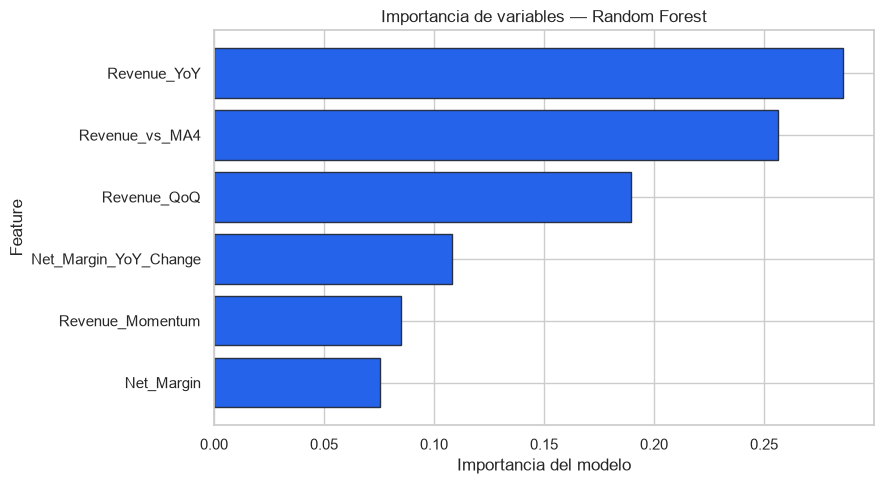

In [15]:
# Etiquetas descriptivas para el refit final de interpretación.
full_labels = historical_cycle["Estado_Ciclo"]
final_feature_dates, final_targets = [], []
for target_date in full_labels.index:
    target_position = financials.index.get_loc(target_date)
    if target_position == 0:
        continue
    feature_date = financials.index[target_position - 1]
    if financials.loc[feature_date, MODEL_FEATURES].isna().any():
        continue
    final_feature_dates.append(feature_date)
    final_targets.append(full_labels.loc[target_date])

X_final = financials.loc[final_feature_dates, MODEL_FEATURES]
y_final = pd.Series(final_targets, index=final_feature_dates)
final_models = {
    name: fit_model(name, template, X_final, y_final)
    for name, template in MODEL_TEMPLATES.items()
}

log_model = final_models["Logistic Regression"]
log_coefficients = pd.DataFrame(
    log_model.named_steps["model"].coef_,
    index=log_model.named_steps["model"].classes_,
    columns=MODEL_FEATURES,
)
tree_importances = pd.DataFrame({
    "Random Forest": final_models["Random Forest"].named_steps["model"].feature_importances_,
    "Gradient Boosting": final_models["Gradient Boosting"].named_steps["model"].feature_importances_,
}, index=MODEL_FEATURES)

display(log_coefficients)
display(tree_importances.sort_values("Random Forest", ascending=False))
log_coefficients.to_csv(OUTPUT_DIR / "coeficientes_logistic_regression.csv")
tree_importances.to_csv(OUTPUT_DIR / "feature_importance_arboles.csv")

if protagonist == "Logistic Regression":
    protagonist_importance = log_coefficients.abs().mean(axis=0).sort_values()
    importance_label = "Promedio |coeficiente estandarizado|"
else:
    protagonist_importance = tree_importances[protagonist].sort_values()
    importance_label = "Importancia del modelo"

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(protagonist_importance.index, protagonist_importance.values, color=BLUE, edgecolor=DARK)
ax.set(title=f"Importancia de variables — {protagonist}", xlabel=importance_label, ylabel="Feature")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "08_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 17. Evaluación orientada a decisión

El modelo se plantea como **sistema de alerta temprana del ciclo operativo**, no como
sistema automático de decisión. Una mayor probabilidad de transición
`Desaceleración → Contracción` podría justificar una revisión gerencial de inventarios,
capital de trabajo, liquidez, CAPEX, endeudamiento y políticas comerciales.

La señal solo prioriza una revisión; la decisión final continúa siendo gerencial.

In [16]:
# Señal prospectiva no evaluada: 2025-Q4 -> 2026-Q1.
latest_date = financials.index.max()
latest_features = financials.loc[[latest_date], MODEL_FEATURES]
final_protagonist = final_models[protagonist]
future_state = final_protagonist.predict(latest_features)[0]
future_probabilities = pd.Series(
    final_protagonist.predict_proba(latest_features)[0],
    index=final_protagonist.named_steps["model"].classes_,
).reindex(STATE_ORDER, fill_value=0).sort_values(ascending=False)
current_state = historical_cycle.loc[latest_date, "Estado_Ciclo"]

display(future_probabilities.rename("Probabilidad estimada").to_frame())
top_two = future_probabilities.iloc[:2]
display(Markdown(
    f"**Señal exploratoria 2026-Q1:** el modelo asigna la mayor probabilidad a "
    f"`{top_two.index[0]}` ({top_two.iloc[0]:.1%}), pero existe simultáneamente una "
    f"probabilidad material de `{top_two.index[1]}` ({top_two.iloc[1]:.1%}). "
    "Por tanto, la señal debe interpretarse como una alerta temprana sujeta a "
    "incertidumbre y no como un pronóstico determinístico. Como el estado real futuro "
    "aún no se conoce, esta observación no aporta evidencia adicional de accuracy."
))
future_probabilities.to_csv(OUTPUT_DIR / "senal_exploratoria_2026Q1.csv")

,Probabilidad estimada
Expansión,0.4716
Contracción,0.3808
Recuperación,0.1212
Desaceleración,0.0264


**Señal exploratoria 2026-Q1:** el modelo asigna la mayor probabilidad a `Expansión` (47.2%), pero existe simultáneamente una probabilidad material de `Contracción` (38.1%). Por tanto, la señal debe interpretarse como una alerta temprana sujeta a incertidumbre y no como un pronóstico determinístico. Como el estado real futuro aún no se conoce, esta observación no aporta evidencia adicional de accuracy.

## 18. Model risk y limitaciones

1. **Muestra pequeña:** 48 trimestres y solo 22 predicciones realmente out-of-time.
2. **Target latente:** las fases dependen del PCA y pueden revisarse al ampliar la ventana.
3. **Cobertura parcial:** faltan venta de equipos nuevos, Product Support, EBIT/EBITDA,
   Free Cash Flow, Backlog, Working Capital y otras variables operacionales relevantes.
4. **Cambios contables:** IFRS 15/9, bases restated y continuing operations reducen
   comparabilidad histórica.
5. **COVID-19 y cambios estructurales:** un régimen excepcional puede no repetirse.
6. **Class imbalance:** Macro F1 y pesos balanceados reducen, pero no eliminan, el riesgo.
7. **Bajo recall de Contracción:** 0.25, con F1 0.20. Es una debilidad material porque
   anticipar contracciones sería uno de los usos financieros más relevantes.
8. **Overfitting:** los modelos se restringen, pero la incertidumbre sigue siendo alta.
9. **Drift:** mix de negocios, regiones, inflación y condiciones sectoriales pueden cambiar.
10. **Sin causalidad:** importancia o coeficientes solo reflejan asociación predictiva.
11. **Etiquetas fold-local:** protegen la evaluación de información futura, pero hacen que
    el significado exacto del índice varíe ligeramente entre orígenes.

## 19. Conclusiones

1. Fue posible construir un Índice de Ciclo Operativo interpretable mediante PCA.
2. PC1 explica 54.6% de la variabilidad en el análisis descriptivo.
3. Se realizaron 22 predicciones verdaderamente out-of-time.
4. Random Forest obtuvo Accuracy 0.545, Balanced Accuracy 0.538 y Macro F1 0.542.
5. Logistic Regression alcanzó Macro F1 0.539; la diferencia es marginal y no permite
   afirmar superioridad estructural del Random Forest.
6. Los modelos superaron el baseline de persistencia en Macro F1, aportando evidencia
   preliminar de capacidad predictiva.
7. Contracción sigue siendo la principal debilidad, con recall 0.25 y F1 0.20.
8. El uso apropiado es una alerta temprana para apoyar una revisión gerencial.
9. El resultado corresponde a una prueba de concepto y **no está listo para producción**.
10. Más historia, variables operacionales y validación externa son necesarias antes de
    considerar una aplicación real.

In [17]:
best_row = model_comparison.loc[model_comparison["Modelo"] == protagonist].iloc[0]
baseline_row = model_comparison.loc[model_comparison["Modelo"] == "Baseline Persistencia"].iloc[0]
worst_recall_state = reports[protagonist].loc[STATE_ORDER, "recall"].idxmin()
top_feature = protagonist_importance.idxmax()

conclusion_table = pd.DataFrame({
    "Pregunta": [
        "¿Fases económicamente razonables?",
        "¿Mejor que persistencia?",
        "Variable más influyente",
        "Estado con menor recall",
        "Uso propuesto",
        "Limitación principal",
    ],
    "Respuesta": [
        f"Sí, con cautela: PC1 explica {cycle_pca.explained_variance_ratio_[0]:.1%} y sus cargas tienen dirección económica coherente.",
        f"{'Sí' if beats_baseline else 'No'}: Macro F1 {best_row['Macro F1']:.3f} vs {baseline_row['Macro F1']:.3f}.",
        top_feature,
        worst_recall_state,
        "Alerta temprana para activar revisión financiera y operacional humana.",
        "Solo 48 trimestres y un target dependiente del PCA.",
    ],
})
display(conclusion_table)
conclusion_table.to_csv(OUTPUT_DIR / "conclusiones_resumen.csv", index=False)

manifest = {
    "data_source": str(DATA_PATH.relative_to(PROJECT_ROOT)),
    "source_sheet": SOURCE_SHEET,
    "as_of": str(raw["Quarter_End"].max().date()),
    "n_quarters": int(len(raw)),
    "n_walk_forward_predictions": int(len(walk_predictions)),
    "pca_features": PCA_FEATURES,
    "model_features": MODEL_FEATURES,
    "protagonist": protagonist,
    "beats_persistence": beats_baseline,
    "random_state": RANDOM_STATE,
}
_ = (OUTPUT_DIR / "run_manifest.json").write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8"
)

,Pregunta,Respuesta
0,¿Fases económicamente razonables?,"Sí, con cautela: PC1 explica 54.6% y sus carga..."
1,¿Mejor que persistencia?,Sí: Macro F1 0.542 vs 0.092.
2,Variable más influyente,Revenue_YoY
3,Estado con menor recall,Contracción
4,Uso propuesto,Alerta temprana para activar revisión financie...
5,Limitación principal,Solo 48 trimestres y un target dependiente del...
